# methylation visualisation
code was originalluy inspired by tutorial from here: https://labs.epi2me.io/notebooks/Modified_Base_Tutorial.html

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import pyranges as pr
import numpy as np
import seaborn as sns


import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 # for proper PDF formatting in Illustrator

In [ ]:
bedmethyl = "ASA_190B_cpg.bed.gz" # choose donor of choice, should be the bed file created by 01_modkit_bed.slurm


In [34]:
methdata = pd.read_csv(
    bedmethyl, sep='\t',
    header=None,
    index_col=False,
    names=["Chromosome", "Start", "End", "name", "score", "strand", "tstart", "tend", "color", "coverage", "freq", "mod", "canon","delete","fail","diff","nocall"])
methdata.head()

/tmp/ipykernel_1718757/460000640.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  methdata = pd.read_csv(


,Chromosome,Start,End,name,score,strand,tstart,tend,color,coverage,freq,mod,canon,delete,fail,diff,nocall
0,chr1,1870,1871,h,2,.,1870,1871,"255,0,0",2,0.0,0,1,1,0,0,3
1,chr1,1870,1871,m,2,.,1870,1871,"255,0,0",2,50.0,1,1,0,0,0,3
2,chr1,1876,1877,h,1,.,1876,1877,"255,0,0",1,0.0,0,0,1,0,0,0
3,chr1,1876,1877,m,1,.,1876,1877,"255,0,0",1,100.0,1,0,0,0,0,0
4,chr1,1882,1883,h,2,.,1882,1883,"255,0,0",2,0.0,0,1,1,0,0,2


In [37]:
# keep only Cs (ms)
methdata = methdata[methdata.name == 'm']

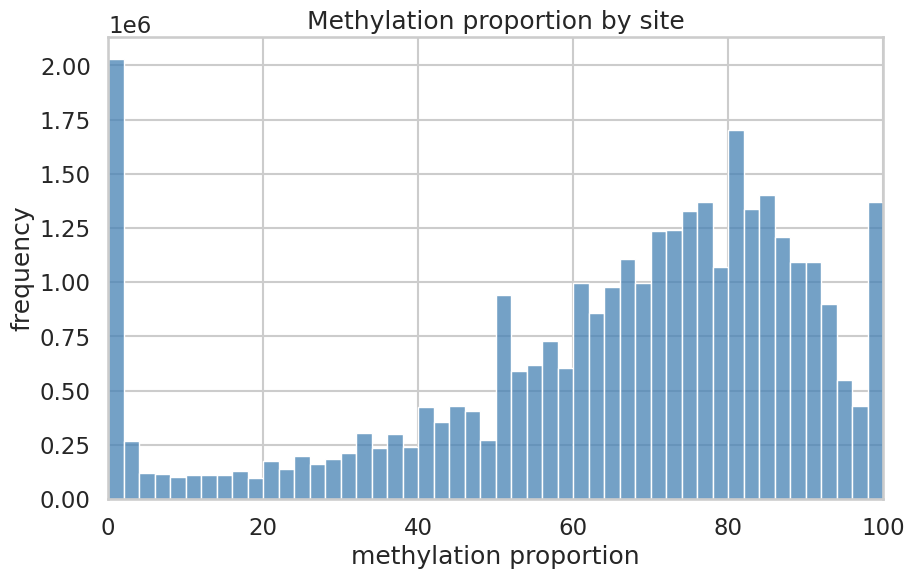

In [ ]:

plt.figure(figsize=(10, 6))
sns.histplot(methdata['freq'], bins=50, color='steelblue')

plt.xlim(0, 100)
plt.title('Methylation proportion by site')
plt.xlabel('methylation proportion')
plt.ylabel('frequency')

# Show the plot
plt.show()

In [39]:
methdata

,Chromosome,Start,End,name,score,strand,tstart,tend,color,coverage,freq,mod,canon,delete,fail,diff,nocall
1,chr1,1870,1871,m,2,.,1870,1871,"255,0,0",2,50.00,1,1,0,0,0,3
3,chr1,1876,1877,m,1,.,1876,1877,"255,0,0",1,100.00,1,0,0,0,0,0
5,chr1,1882,1883,m,2,.,1882,1883,"255,0,0",2,50.00,1,1,0,0,0,2
7,chr1,1888,1889,m,1,.,1888,1889,"255,0,0",1,100.00,1,0,0,0,0,0
9,chr1,1894,1895,m,1,.,1894,1895,"255,0,0",1,100.00,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65951631,chrM,16448,16449,m,3694,.,16448,16449,"255,0,0",3694,0.08,3,3666,25,24,99,52
65951633,chrM,16453,16454,m,3815,.,16453,16454,"255,0,0",3815,0.21,8,3795,12,35,71,47
65951635,chrM,16494,16495,m,3590,.,16494,16495,"255,0,0",3590,0.22,8,3522,60,31,248,98
65951637,chrM,16541,16542,m,3824,.,16541,16542,"255,0,0",3824,0.00,0,3811,13,10,47,18


In [40]:
methdata = methdata[methdata.coverage > 5] # check only if certain coverage

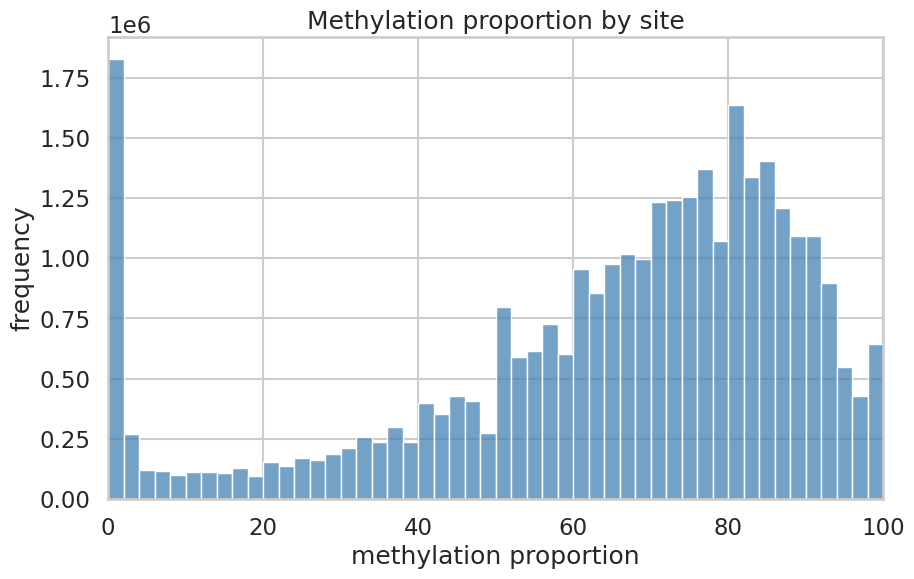

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(methdata['freq'], bins=50, color='steelblue')

plt.xlim(0, 100)
plt.title('Methylation proportion by site')
plt.xlabel('methylation proportion')
plt.ylabel('frequency')


plt.show()

# CTCF visualisation

in command line <br>
the chain file from hg38 to T2T is needed

```
# CTCF sites
# from: https://unibind.uio.no/factor/EXP051029.GM12878_female_B-cells_lymphoblastoid_cell_line.CTCF/ 
wget https://unibind.uio.no/static/data/20220914/macs/DAMO/EXP051029.GM12878_female_B-cells_lymphoblastoid_cell_line.CTCF/EXP051029.GM12878_female_B-cells_lymphoblastoid_cell_line.CTCF.MA0139.1.damo.bed
# liftOver
ml Kent_tools/20230302
liftOver EXP051029.GM12878_female_B-cells_lymphoblastoid_cell_line.CTCF.MA0139.1.damo.bed chainfiles/hg38-chm13v2.over.chain.gz GM12878.CTCF.lift.chm13v2.bed unmapped_CTCF.bed
```

In [ ]:
ctcf_path = "EXP051029.t2t.sort.bed" # path to CTCF peaks bed file
ctcf = pd.read_csv(
    ctcf_path, sep='\t',
    header=None,
    index_col=False,
    names=["Chromosome", "Start", "End", ".", "height", "strand_b","2","3","4","5"])
ctcf.head()

,Chromosome,Start,End,.,height,strand_b,2,3,4,5
0,chr1,205337,205356,CTCF_CGGCCACCAGTAGGCAGCG,83.5,-,NaN,NaN,NaN,NaN
1,chr1,298891,298910,CTCF_CTGCCACCAGGGGGCGCGC,94.6,+,NaN,NaN,NaN,NaN
2,chr1,334756,334775,CTCF_CCGCCACCAGGGGGCGCCA,98.3,+,NaN,NaN,NaN,NaN
3,chr1,366994,367013,CTCF_AGCCCAGCAGGTGGCAGAG,85.5,-,NaN,NaN,NaN,NaN
4,chr1,404916,404935,CTCF_CCGCCGGCAGGTGGGGCAA,83.9,-,NaN,NaN,NaN,NaN


In [ ]:
# increase and recenter at midpoint // careful, slack function in pyranges will not recenter motif
width = 4000
mid = ((ctcf['Start'] + ctcf['End']) // 2)
ctcf['Start'] = (mid - width // 2).astype(int)
ctcf['End'] = ctcf['Start']  + width

ctcf_r = pr.PyRanges(ctcf)

methdata_r = pr.PyRanges(methdata)
# overlap the two
overlap_ctcf = methdata_r.join(ctcf_r, how = None)
overlap_ctcf

,Chromosome,Start,End,name,score,strand,tstart,tend,color,coverage,...,nocall,Start_b,End_b,.,height,strand_b,2,3,4,5
0,chr1,203383,203384,m,35,.,203383,203384,"255,0,0",35,...,0,203346,207346,CTCF_CGGCCACCAGTAGGCAGCG,83.5,-,NaN,NaN,NaN,NaN
1,chr1,203588,203589,m,37,.,203588,203589,"255,0,0",37,...,1,203346,207346,CTCF_CGGCCACCAGTAGGCAGCG,83.5,-,NaN,NaN,NaN,NaN
2,chr1,203602,203603,m,33,.,203602,203603,"255,0,0",33,...,0,203346,207346,CTCF_CGGCCACCAGTAGGCAGCG,83.5,-,NaN,NaN,NaN,NaN
3,chr1,203701,203702,m,31,.,203701,203702,"255,0,0",31,...,0,203346,207346,CTCF_CGGCCACCAGTAGGCAGCG,83.5,-,NaN,NaN,NaN,NaN
4,chr1,203741,203742,m,30,.,203741,203742,"255,0,0",30,...,0,203346,207346,CTCF_CGGCCACCAGTAGGCAGCG,83.5,-,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914150,chrX,154196270,154196271,m,18,.,154196270,154196271,"255,0,0",18,...,0,154193095,154197095,CTCF_CAGCCACCAGATGGCATGT,87.3,+,NaN,NaN,NaN,NaN
1914151,chrX,154196510,154196511,m,16,.,154196510,154196511,"255,0,0",16,...,2,154193095,154197095,CTCF_CAGCCACCAGATGGCATGT,87.3,+,NaN,NaN,NaN,NaN
1914152,chrX,154196901,154196902,m,20,.,154196901,154196902,"255,0,0",20,...,0,154193095,154197095,CTCF_CAGCCACCAGATGGCATGT,87.3,+,NaN,NaN,NaN,NaN
1914153,chrX,154196988,154196989,m,22,.,154196988,154196989,"255,0,0",22,...,0,154193095,154197095,CTCF_CAGCCACCAGATGGCATGT,87.3,+,NaN,NaN,NaN,NaN


In [ ]:
overlap_ctcf_df = overlap_ctcf.df
# Calculate relative position first
overlap_ctcf_df['relpos'] = overlap_ctcf_df.apply(lambda row: row['Start'] - (row['Start_b'] + row['End_b']) / 2 
                           if row['strand_b'] in ['+', '.'] 
                           else (row['Start_b'] + row['End_b']) / 2 - row['Start'], 
                           axis=1)

meanmeth = overlap_ctcf_df.groupby('relpos').apply(lambda x: (x['freq'].mean())).reset_index(name='frac')

In [45]:
meanmeth

,relpos,frac
0,-2000.0,57.755918
1,-1999.0,54.822072
2,-1998.0,57.793587
3,-1997.0,56.003521
4,-1996.0,57.116150
...,...,...
3996,1996.0,54.441318
3997,1997.0,55.699000
3998,1998.0,53.781518
3999,1999.0,52.693139


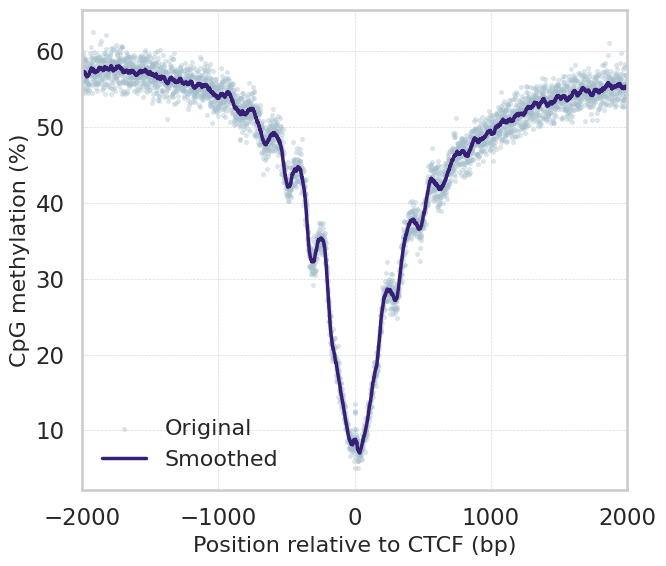

In [ ]:
# Calculate smoothed frac
meanmeth['smoothed_frac'] = meanmeth['frac'].rolling(window=30, min_periods=1, center=True).mean()
sns.set(style="whitegrid", context="talk", font_scale=1.0)

plt.figure(figsize=(7, 6))

# Scatter plot for original frac
sns.scatterplot(
    data=meanmeth, x='relpos', y='frac',
    color='#A5BFCC', label='Original', alpha=0.4, s=10, edgecolor=None, legend = None
)

# Line plot for smoothed frac
sns.lineplot(
    data=meanmeth, x='relpos', y='smoothed_frac',
    color='#371F76', label='Smoothed', linewidth=2.5
)

plt.title('')
plt.xlabel('Position relative to CTCF (bp)', fontsize=16)
plt.ylabel('CpG methylation (%)', fontsize=16)
plt.xlim(-2000, 2000)
plt.legend(frameon=False, fontsize=16)
plt.tight_layout()

plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)


plt.savefig("ASA_190.CTCF.pdf")

plt.show()

# TSS enrichment

In [49]:
tss_path = "/staging/leuven/res_00001/genomes/homo_sapiens/CHM13v2_maskedY_rCRS/annotations/CHM13v2_maskedY_rCRS.tss.bed" 
tss = pd.read_csv(
    tss_path, sep='\t',
    header=None,
    index_col=False,
    names=["Chromosome", "Start", "End", "gene_name", "x", "strand"])
tss.head()


,Chromosome,Start,End,gene_name,x,strand
0,chrX,105171,105172,LOC124905300_1,.,-
1,chrX,104530,104531,PLCXD1,.,+
2,chrX,149850,149851,GTPBP6,.,-
3,chrX,150199,150200,LINC00685,.,+
4,chrX,218171,218172,PPP2R3B,.,-


In [51]:
# add info on expression - so we only check TSS at Top and bottom genes
expression_low = pd.read_csv('expression_info/cc_Oligo_bottom10_expressed_genes.csv')  # oligo
expression_low['expression'] = 'low'
expression_high = pd.read_csv('expression_info/cc_Oligo_top10_expressed_genes.csv')
expression_high['expression'] = 'high'
expression = pd.concat([expression_high, expression_low], ignore_index=True)
expression

,gene,expression
0,MALAT1,high
1,PCDH9,high
2,IL1RAPL1,high
3,QKI,high
4,DLG2,high
...,...,...
7897,TRAV6,low
7898,TRAV7,low
7899,TRAV8-1,low
7900,TRAV8-2,low


In [52]:
tss = pd.merge(tss, expression, how = 'left', right_on = 'gene', left_on = 'gene_name')
tss

,Chromosome,Start,End,gene_name,x,strand,gene,expression
0,chrX,105171,105172,LOC124905300_1,.,-,NaN,NaN
1,chrX,104530,104531,PLCXD1,.,+,NaN,NaN
2,chrX,149850,149851,GTPBP6,.,-,NaN,NaN
3,chrX,150199,150200,LINC00685,.,+,NaN,NaN
4,chrX,218171,218172,PPP2R3B,.,-,NaN,NaN
...,...,...,...,...,...,...,...,...
42122,chrM,10469,10470,MT-ND4L,.,+,MT-ND4L,high
42123,chrM,10759,10760,MT-ND4,.,+,MT-ND4,high
42124,chrM,12336,12337,MT-ND5,.,+,MT-ND5,high
42125,chrM,14672,14673,MT-ND6,.,-,NaN,NaN


In [ ]:
tss_r = pr.PyRanges(tss)
tss_r = tss_r.slack(2000)
methdata_r = pr.PyRanges(methdata)
# overlap the two
overlap = methdata_r.join(tss_r, how = None)
overlap

,Chromosome,Start,End,name,score,strand,tstart,tend,color,coverage,...,fail,diff,nocall,Start_b,End_b,gene_name,x,strand_b,gene,expression
0,chr1,12079,12080,m,21,.,12079,12080,"255,0,0",21,...,1,0,0,11940,15941,LOC124900618,.,-,NaN,NaN
1,chr1,12117,12118,m,20,.,12117,12118,"255,0,0",20,...,1,2,0,11940,15941,LOC124900618,.,-,NaN,NaN
2,chr1,12131,12132,m,22,.,12131,12132,"255,0,0",22,...,0,1,0,11940,15941,LOC124900618,.,-,NaN,NaN
3,chr1,12319,12320,m,20,.,12319,12320,"255,0,0",20,...,0,0,1,11940,15941,LOC124900618,.,-,NaN,NaN
4,chr1,12324,12325,m,17,.,12324,12325,"255,0,0",17,...,0,4,0,11940,15941,LOC124900618,.,-,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4215476,chrY,27222464,27222465,m,14,.,27222464,27222465,"255,0,0",14,...,0,1,0,27219043,27223044,LOC105377244,.,-,NaN,NaN
4215477,chrY,27222606,27222607,m,11,.,27222606,27222607,"255,0,0",11,...,1,1,0,27219043,27223044,LOC105377244,.,-,NaN,NaN
4215478,chrY,27222988,27222989,m,8,.,27222988,27222989,"255,0,0",8,...,0,1,1,27219043,27223044,LOC105377244,.,-,NaN,NaN
4215479,chrY,27222998,27222999,m,7,.,27222998,27222999,"255,0,0",7,...,0,2,1,27219043,27223044,LOC105377244,.,-,NaN,NaN


In [ ]:
overlap_df = overlap.df # back to pandas

In [57]:
overlap_df.columns

Index(['Chromosome', 'Start', 'End', 'name', 'score', 'strand', 'tstart',
       'tend', 'color', 'coverage', 'freq', 'mod', 'canon', 'delete', 'fail',
       'diff', 'nocall', 'Start_b', 'End_b', 'gene_name', 'x', 'strand_b',
       'gene', 'expression'],
      dtype='object')

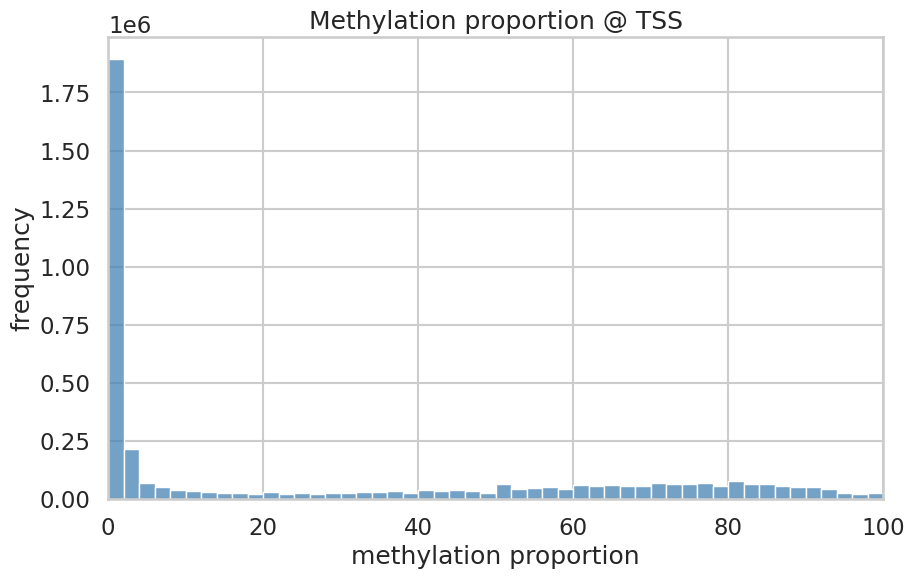

In [ ]:
# Create the histogram using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(overlap_df['freq'], bins=50, color='steelblue')

plt.xlim(0, 100)
plt.title('Methylation proportion @ TSS')
plt.xlabel('methylation proportion')
plt.ylabel('frequency')
plt.show()

In [59]:
# Calculate relative position first
overlap_df['relpos'] = overlap_df.apply(lambda row: row['Start'] - (row['Start_b'] + row['End_b']) / 2 
                           if row['strand_b'] in ['+', '.'] 
                           else (row['Start_b'] + row['End_b']) / 2 - row['Start'], 
                           axis=1)

# Filter out rows where expression is NaN
overlap_df_filtered = overlap_df.dropna(subset=['expression'])

# Create dictionary
meanmeth_dict = {}
for expr_val in overlap_df_filtered['expression'].unique():
    subset = overlap_df_filtered[overlap_df_filtered['expression'] == expr_val]
    meanmeth_dict[expr_val] = subset.groupby('relpos')['freq'].mean().reset_index(name='frac')

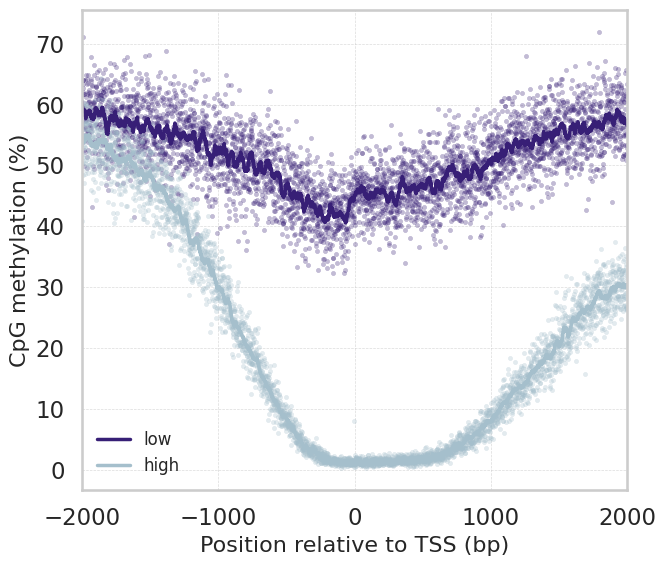

In [ ]:

# Set style and context for publication
sns.set(style="whitegrid", context="talk", font_scale=1.0)

plt.figure(figsize=(7, 6))

# colors for different expression levels
custom_colors = ['#371F76', '#A5BFCC']

for i, (expr_val, meanmeth) in enumerate(meanmeth_dict.items()):
    # Calculate smoothed frac
    meanmeth['smoothed_frac'] = meanmeth['frac'].rolling(window=30, min_periods=1, center=True).mean()
    
    # Scatter plot for raw values
    sns.scatterplot(
        data=meanmeth, x='relpos', y='frac',
        color=custom_colors[i], alpha=0.3, s=10, edgecolor=None,
        label=None
    )
    
    # Line plot for smoothed values
    sns.lineplot(
        data=meanmeth, x='relpos', y='smoothed_frac',
        color=custom_colors[i], linewidth=2.5,
        label=f'{expr_val}'
    )

plt.title('', fontsize=18, weight='bold')
plt.xlabel('Position relative to TSS (bp)', fontsize=16)
plt.ylabel('CpG methylation (%)', fontsize=16)
plt.xlim(-2000, 2000)
plt.legend(loc='lower left', fontsize = 12,     
    frameon=False, )
plt.tight_layout()
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)

# Optional: Save as high-res image
plt.savefig("ASA_190_TSS_oligo_cpg.pdf", dpi=300, bbox_inches='tight')

plt.show()